# Transformation to C Code (Simple)

## Imports

In [ ]:
# | code-fold: true
# | code-summary: "Load packages"
# | output: false

import os
import numpy as np

from zoomy_core.model.models.shallow_water import ShallowWaterEquations as SWE
from zoomy_core.model.models.shallow_water_topo import NumericalShallowWaterEquationsWithTopo 

import zoomy_core.model.initial_conditions as IC
import zoomy_core.model.boundary_conditions as BC
from zoomy_core.misc.misc import Zstruct, Settings
from zoomy_core.transformation.to_c import CppModel, CppNumerics
import zoomy_core.misc.misc as misc
from zoomy_core.transformation.functions import conditional



## Model definition

In [ ]:
bcs = BC.BoundaryConditions(
    [
        BC.Wall(tag="wall"),
        BC.Wall(tag="inflow"),
        BC.Wall(tag="outflow"),
    ]
)

def custom_ic(x):
    Q = np.zeros(4, dtype=float)
    Q[1] = np.where(x[0] < 5., 0.005, 0.001)
    return Q

ic = IC.UserFunction(custom_ic)

class SWEB(NumericalShallowWaterEquationsWithTopo):
    
    def initial_condition(self):
        X = self.position
        p = self.parameters
        out = misc.ZArray.zeros(self.n_variables)
        out[0] = 1.
        out[1] = conditional(X[0] < 5, 2., 1.)
        return out

    def initial_aux_condition(self):
        X = self.position
        p = self.parameters
        out = misc.ZArray.zeros(self.n_aux_variables)
        out[0] = conditional(X[0] < 5, 1./2., 1./1.)
        return out
    

model = SWEB(
    dimension=2,
    boundary_conditions=bcs,
    initial_conditions=ic,
    aux_variables=1,
)


## Sympy Model

In [ ]:
import sympy as sp

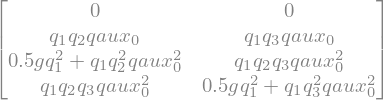

In [ ]:
model.flux()

In [ ]:
model.functions.flux.args

Zstruct(variables=Zstruct(q0=q0, q1=q1, q2=q2, q3=q3), aux_variables=Zstruct(qaux0=qaux0), p=Zstruct(g=g, chezy_C=chezy_C, eps=eps))

In [ ]:
print(model.call.flux())

[[0, 0], [q1*q2*qaux0, q1*q3*qaux0], [0.5*g*q1**2 + q1*q2**2*qaux0**2, q1*q2*q3*qaux0**2], [q1*q2*q3*qaux0**2, 0.5*g*q1**2 + q1*q3**2*qaux0**2]]


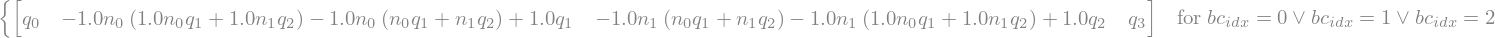

In [ ]:
model.print_boundary_conditions()

## Code transformation

In [ ]:
settings = Settings(name="ShallowWater", output=Zstruct(directory="outputs/trafo", filename="swe.h5", clean_directory=True, snapshots=30))
CppModel.write_code(model, settings)


'/home/ingo/Git/Zoomy/outputs/trafo/.c_interface/Model.H'

In [ ]:
! cp /home/ingo/Git/Zoomy/outputs/trafo/.c_interface/Model.H /home/ingo/Git/Zoomy/library/zoomy_dmplex

In [ ]:
from zoomy_core.fvm.symbolic_numerics import PositiveRusanov, Rusanov

In [ ]:
# numerics = PositiveRusanov(model)
# numerics = Rusanov(model)

class Numa(Rusanov):
    def overwrite_q_qaux(self):
        Q = self.model.variables
        Qaux = self.model.aux_variables
        eps = self.model.parameters.eps
        Qaux[0] = conditional(Q[1] > eps, 1./Q[1], eps)
        return Q, Qaux
        
numerics = Numa(model)

In [ ]:
print(model.flux())
print(model.call.flux())

[[0, 0], [q1*q2*conditional(q1 > eps, 1.0/q1, eps), q1*q3*conditional(q1 > eps, 1.0/q1, eps)], [0.5*g*q1**2 + q1*q2**2*conditional(q1 > eps, 1.0/q1, eps)**2, q1*q2*q3*conditional(q1 > eps, 1.0/q1, eps)**2], [q1*q2*q3*conditional(q1 > eps, 1.0/q1, eps)**2, 0.5*g*q1**2 + q1*q3**2*conditional(q1 > eps, 1.0/q1, eps)**2]]
[[0, 0], [q1*q2*qaux0, q1*q3*qaux0], [0.5*g*q1**2 + q1*q2**2*qaux0**2, q1*q2*q3*qaux0**2], [q1*q2*q3*qaux0**2, 0.5*g*q1**2 + q1*q3**2*qaux0**2]]


In [ ]:
print(numerics.numerical_flux())
print(numerics.call.numerical_flux())

[0.5*n0*Model<T>::flux(Q_minus, Qaux_minus, p)[0] + 0.5*n0*Model<T>::flux(Q_plus, Qaux_plus, p)[0] + 0.5*n1*Model<T>::flux(Q_minus, Qaux_minus, p)[1] + 0.5*n1*Model<T>::flux(Q_plus, Qaux_plus, p)[1] - 0.5*(-Q_minus_0 + Q_plus_0)*Max(Abs(Model<T>::eigenvalues(Q_minus, Qaux_minus, p, n)[0]), Abs(Model<T>::eigenvalues(Q_minus, Qaux_minus, p, n)[1]), Abs(Model<T>::eigenvalues(Q_minus, Qaux_minus, p, n)[2]), Abs(Model<T>::eigenvalues(Q_minus, Qaux_minus, p, n)[3]), Abs(Model<T>::eigenvalues(Q_plus, Qaux_plus, p, n)[0]), Abs(Model<T>::eigenvalues(Q_plus, Qaux_plus, p, n)[1]), Abs(Model<T>::eigenvalues(Q_plus, Qaux_plus, p, n)[2]), Abs(Model<T>::eigenvalues(Q_plus, Qaux_plus, p, n)[3])), 0.5*n0*Model<T>::flux(Q_minus, Qaux_minus, p)[2] + 0.5*n0*Model<T>::flux(Q_plus, Qaux_plus, p)[2] + 0.5*n1*Model<T>::flux(Q_minus, Qaux_minus, p)[3] + 0.5*n1*Model<T>::flux(Q_plus, Qaux_plus, p)[3] - 0.5*(-Q_minus_1 + Q_plus_1)*Max(Abs(Model<T>::eigenvalues(Q_minus, Qaux_minus, p, n)[0]), Abs(Model<T>::eigenv

In [ ]:
numerics.numerical_flux()

In [ ]:
CppNumerics.write_code(numerics, settings)

'/home/ingo/Git/Zoomy/outputs/trafo/.c_interface/Numerics.H'

In [ ]:
! cp /home/ingo/Git/Zoomy/outputs/trafo/.c_interface/Numerics.H /home/ingo/Git/Zoomy/library/zoomy_dmplex


## Check the output

In [ ]:
main_dir = misc.get_main_directory()
path = os.path.join(main_dir, os.path.join(settings.output.directory, '.c_interface/Model.H'))
with open(path, "r") as f:
    print(f.read())


#pragma once
#include <cmath>
#include <array>

#ifndef ZOOMY_SIMPLE_ARRAY
#define ZOOMY_SIMPLE_ARRAY
template <typename T, int N>
struct SimpleArray {
    T data[N];
    T& operator[](int i) { return data[i]; }
    const T& operator[](int i) const { return data[i]; }
    T* begin() { return data; }
    const T* begin() const { return data; }
    T* end() { return data + N; }
    const T* end() const { return data + N; }
};
#endif

#include <vector>
#include <string>
#include <algorithm>

#ifdef __CUDACC__
#define PORTABLE_FN __host__ __device__
#else
#define PORTABLE_FN
#endif

template <typename T>
struct Model {
    static constexpr int n_dof_q    = 4;
    static constexpr int n_dof_qaux = 1;
    static constexpr int dimension  = 2;
    static constexpr int n_boundary_tags = 3;
    static const std::vector<std::string> get_boundary_tags() { return { "inflow", "outflow", "wall" }; }
    PORTABLE_FN static inline SimpleArray<T, 8> flux(
        const T* Q,
        const T* Qaux,
     

In [ ]:
main_dir = misc.get_main_directory()
path = os.path.join(
    main_dir, os.path.join(settings.output.directory, ".c_interface/Numerics.H")
)
with open(path, "r") as f:
    print(f.read())


#pragma once
#include <cmath>
#include <array>

#ifndef ZOOMY_SIMPLE_ARRAY
#define ZOOMY_SIMPLE_ARRAY
template <typename T, int N>
struct SimpleArray {
    T data[N];
    T& operator[](int i) { return data[i]; }
    const T& operator[](int i) const { return data[i]; }
    T* begin() { return data; }
    const T* begin() const { return data; }
    T* end() { return data + N; }
    const T* end() const { return data + N; }
};
#endif

#include <vector>
#include <algorithm>

#ifdef __CUDACC__
#define PORTABLE_FN __host__ __device__
#else
#define PORTABLE_FN
#endif

template <typename T>
struct Numerics {
    static constexpr int n_dof_q = 4;
    PORTABLE_FN static inline SimpleArray<T, 4> numerical_flux(
        const T* Q_minus,
        const T* Q_plus,
        const T* Qaux_minus,
        const T* Qaux_plus,
        const T* p,
        const T* n)
    {
    auto v_call_0 = Model<T>::flux(Q_minus, Qaux_minus, p);
    auto v_call_1 = Model<T>::flux(Q_plus, Qaux_plus, p);
    auto v_call_2 

In [ ]:
main_dir = misc.get_main_directory()
path = os.path.join(
    main_dir, os.path.join(main_dir, "library/zoomy_dmplex/Numerics.H")
)
with open(path, "r") as f:
    print(f.read())


#pragma once
#include <cmath>
#include <array>

#ifndef ZOOMY_SIMPLE_ARRAY
#define ZOOMY_SIMPLE_ARRAY
template <typename T, int N>
struct SimpleArray {
    T data[N];
    T& operator[](int i) { return data[i]; }
    const T& operator[](int i) const { return data[i]; }
    T* begin() { return data; }
    const T* begin() const { return data; }
    T* end() { return data + N; }
    const T* end() const { return data + N; }
};
#endif

#include <vector>
#include <algorithm>

#ifdef __CUDACC__
#define PORTABLE_FN __host__ __device__
#else
#define PORTABLE_FN
#endif

template <typename T>
struct Numerics {
    static constexpr int n_dof_q = 4;
    PORTABLE_FN static inline SimpleArray<T, 4> numerical_flux(
        const T* Q_minus,
        const T* Q_plus,
        const T* Qaux_minus,
        const T* Qaux_plus,
        const T* p,
        const T* n)
    {
    auto v_call_0 = Model<T>::flux(Q_minus, Qaux_minus, p);
    auto v_call_1 = Model<T>::flux(Q_plus, Qaux_plus, p);
    auto v_call_2 